In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,auc
from sklearn.datasets import load_digits, load_breast_cancer
import joblib # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf

# keras 모델 저장 및 로드 기능 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, MaxPooling2D, Flatten, Conv2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist


np.random.seed(42)
tf.random.set_seed(42)

In [11]:
# ======================================
# 1 데이터 가져오기
# ======================================


(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [ ]:
mnist.load_data

In [13]:

# 클래스 이름 정의
class_names = [
    'zero', 'one','two','three','four','five','six','seven','eight','nine'
]

# 데이터 shape 확인
print('X_train shape : ',X_train.shape)
print('X_test shape : ',X_test.shape)


X_train shape :  (60000, 28, 28)
X_test shape :  (10000, 28, 28)


In [14]:
# ======================================
# 2. 데이터 정규화
# ======================================

# 픽셀값 0~1 범위로 정규화
X_train = X_train / 255.0 # 0 ~ 255 사이에서 크게 널뛰던 픽셀 값들이 0.0 ~ 1.0 사이의 값이 됨.
X_test = X_test / 255.0

# CNN 입력 형태에 맞게 채널 차원을 Reshape
X_train = X_train.reshape(-1, 28,28, 1)
X_test = X_test.reshape(-1, 28,28, 1)

In [15]:
# ======================================
# 3. 모델 정의
# ======================================

# 순차형 신경망 생성
model = Sequential()

# 첫 번째 합성곱 층을 추가
model.add(
    Conv2D(32, kernel_size=(3, 3),
           activation='relu',
           input_shape=(28, 28, 1)))

# 풀링 층 추가
model.add(MaxPooling2D(pool_size=(2, 2)))

# 두 번째 합성곱 층을 추가
model.add(Conv2D(64, (3, 3), activation='relu'))

# 두 번째 풀링 추가
model.add(MaxPooling2D(pool_size=(2, 2)))

# 1차원 벡터로 펼침
model.add(Flatten())
model.add(Dense(128, activation='relu'))

#드롭아웃 추가
model.add(Dropout(0.3))

# 출력층 추가
model.add(Dense(10, activation='softmax'))

D:\anaconda3\envs\analyzer\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# ======================================
# 4. 모델 컴파일
# ======================================

# 모델 컴파일 설정
model.compile(
    optimizer= "adam",
    # loss = "categorical_crossentropy",
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 학습 조기 종료 설정
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [17]:
# ======================================
# 5. 모델 학습
# ======================================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs = 20,
    batch_size = 64,
    callbacks = [early_stop],
    verbose = 1
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9330 - loss: 0.2172 - val_accuracy: 0.9832 - val_loss: 0.0584
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9793 - loss: 0.0704 - val_accuracy: 0.9862 - val_loss: 0.0439
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9848 - loss: 0.0490 - val_accuracy: 0.9884 - val_loss: 0.0405
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9877 - loss: 0.0389 - val_accuracy: 0.9899 - val_loss: 0.0400
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9899 - loss: 0.0309 - val_accuracy: 0.9899 - val_loss: 0.0412
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9914 - loss: 0.0261 - val_accuracy: 0.9897 - val_loss: 0.0415
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9926 - loss: 0.0221 - val_accuracy: 0.9893 - val_loss: 0.0441
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9937 - loss: 0.0192 - 

In [18]:
# ======================================
# 6. 성능 평가
# ======================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

#결과 출력
print("테스트 손실 : ",test_loss )
print("테스트 정확도 : ",test_acc )

테스트 손실 :  0.03300360217690468
테스트 정확도 :  0.9889000058174133


In [20]:
# ======================================
# 7. 예측 확률 계산
# ======================================

# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [21]:
# ======================================
# 8. 학습 결과 저장
# ======================================
# 모델 학습 결과 저장
model.save("./data/results/cnn_mnist_number.h5")

# 모델 학습 결과 읽어오기
loaded_model = tf.keras.models.load_model('./data/results/cnn_mnist_number.h5')

In [22]:
# ======================================
# 9. 신규 데이터 예측 / 분류
#======================================
new_images = X_test[:5]

# 신규 이미지 예측
new_prob = loaded_model.predict(new_images)

# 최종 클래스 예측값 계산
new_pred = np.argmax(new_prob, axis=1)

# 예측결과 출력
for i in range(len(new_images)):
    print(f"{i+1}번 이미지 - 예측 클래스 : {new_pred[i]} ({class_names[new_pred[i]]})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1번 이미지 - 예측 클래스 : 7 (seven)
2번 이미지 - 예측 클래스 : 2 (two)
3번 이미지 - 예측 클래스 : 1 (one)
4번 이미지 - 예측 클래스 : 0 (zero)
5번 이미지 - 예측 클래스 : 4 (four)


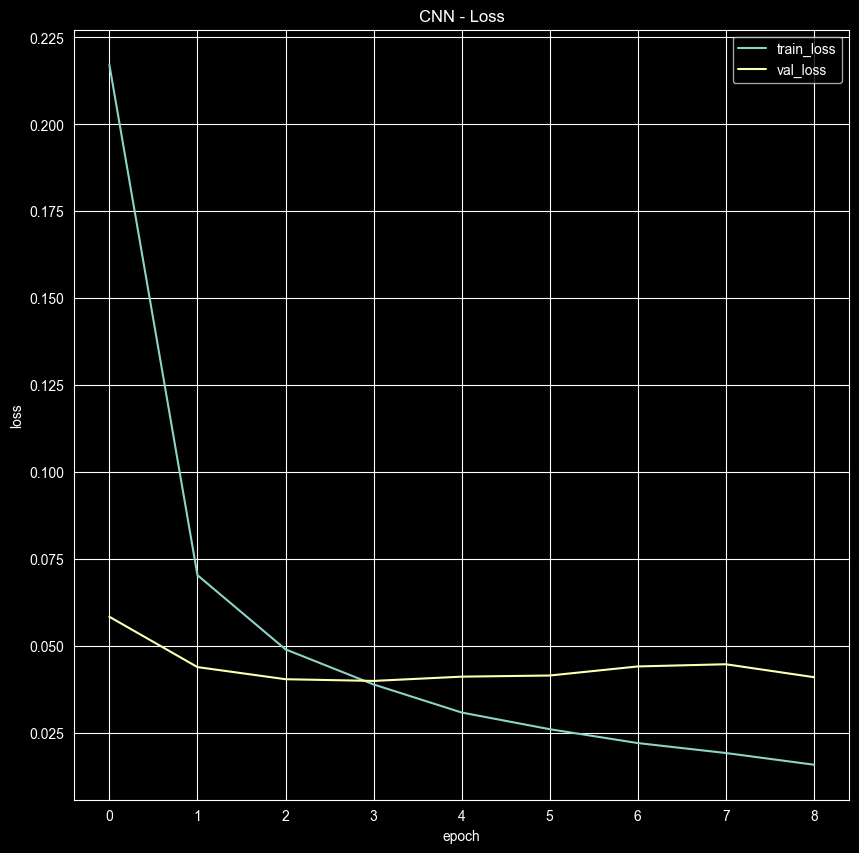

In [23]:
# ======================================
# 10. 결과 시각화
#======================================

# 학습 손실 그래프
plt.figure(figsize=(10,10))
plt.plot(history.history['loss'],label = 'train_loss' )
plt.plot(history.history['val_loss'],label = 'val_loss')
plt.title('CNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

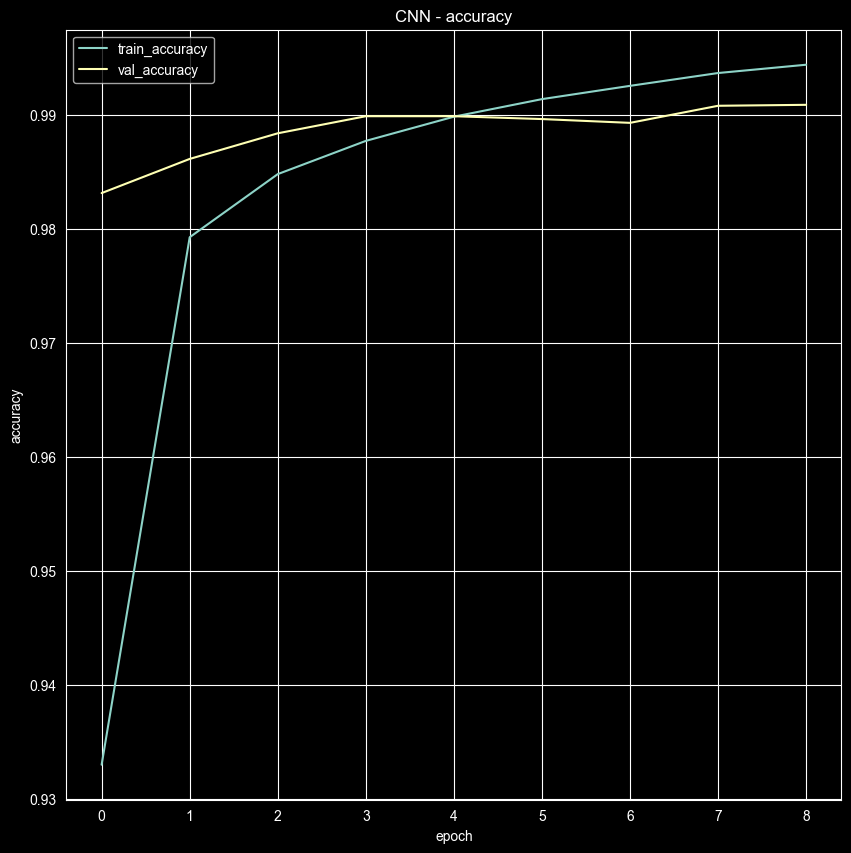

In [24]:
# 학습 정확도 그래프
plt.figure(figsize=(10,10))
plt.plot(history.history['accuracy'],label = 'train_accuracy' )
plt.plot(history.history['val_accuracy'],label = 'val_accuracy')
plt.title('CNN - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
plt.show()

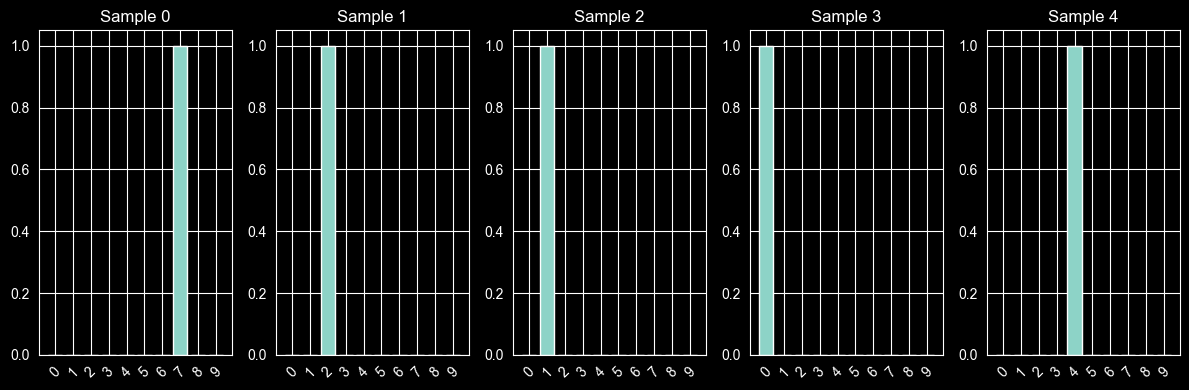

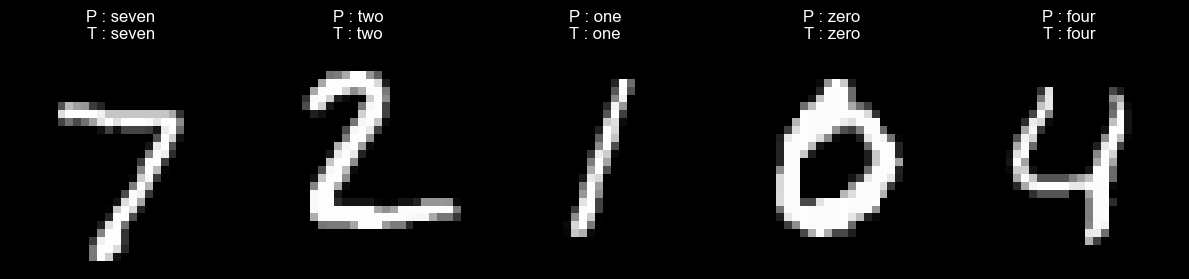

In [27]:
# 테스트 이미지와 예측 결과 시각화

plt.figure(figsize=(12,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.bar(range(10), new_prob[i])
    plt.title(f"Sample {i}")
    plt.xticks(range(10), rotation=45)

plt.tight_layout()
plt.show()


# 신규 이미지 5개에 대한 확률 분포 시각화
plt.figure(figsize=(12,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P : {class_names[y_pred[i]]}\nT : {class_names[y_test[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()